## 1) a) 

In [66]:
import pandas as pd
import sqlite3
import regex as re
import spacy

In [67]:
# Read database (from HW1) into a DataFrame
con = sqlite3.connect("wiki_articles_hw1.db")

cursor = con.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

df = pd.read_sql_query("SELECT * from wiki_articles_hw1", con)

con.close()

nlp = spacy.load("en_core_web_lg")
df

[('wiki_articles_hw1',)]


,title,text,name,url,datePublished,dateModified,headline
0,Acne,"From Wikipedia, the free encyclopedia\n\n\nSki...",Acne,https://en.wikipedia.org/wiki/Acne,2002-08-22T01:27:34Z,2025-01-10T12:50:12Z,sebaceous gland's disease characterized by are...
1,Alcoholic liver disease,"From Wikipedia, the free encyclopedia\n\n\n\n\...",Alcoholic liver disease,https://en.wikipedia.org/wiki/Alcoholic_liver_...,2003-08-29T06:49:59Z,2024-12-10T17:39:27Z,medical condition
2,Alcoholism,"From Wikipedia, the free encyclopedia\n\n\nPro...",Alcoholism,https://en.wikipedia.org/wiki/Alcoholism,2001-12-20T15:13:43Z,2025-01-19T22:28:08Z,broad term for problems with alcohol
3,Allergic rhinitis,"From Wikipedia, the free encyclopedia\n\n\nNas...",Allergic rhinitis,https://en.wikipedia.org/wiki/Allergic_rhinitis,2003-12-24T04:16:09Z,2024-11-26T19:41:50Z,human disease డ్యూ తో inflammation in nose oc...
4,Allergy,"From Wikipedia, the free encyclopedia\n\n\nImm...",Allergy,https://en.wikipedia.org/wiki/Allergy,2002-06-07T10:03:08Z,2025-01-21T15:29:18Z,immune system response to a substance that mos...
...,...,...,...,...,...,...,...
228,Waterborne disease,"From Wikipedia, the free encyclopedia\n\n(Redi...",Waterborne disease,https://en.wikipedia.org/wiki/Waterborne_disease,2006-03-18T13:23:48Z,2024-11-30T14:28:25Z,disease caused by pathogenic microorganisms th...
229,White coat hypertension,"From Wikipedia, the free encyclopedia\n\n\nMed...",White coat hypertension,https://en.wikipedia.org/wiki/White_coat_hyper...,2004-11-21T03:20:18Z,2024-08-28T21:13:13Z,medical condition
230,Whooping cough,"From Wikipedia, the free encyclopedia\n\n\nHum...",Whooping cough,https://en.wikipedia.org/wiki/Whooping_cough,2003-01-19T01:47:04Z,2024-12-20T01:24:18Z,human disease caused by the bacteria Bordetell...
231,Yellow fever,"From Wikipedia, the free encyclopedia\n\n\nVir...",Yellow fever,https://en.wikipedia.org/wiki/Yellow_fever,2001-06-12T18:00:45Z,2025-01-14T19:20:36Z,viral disease


## 1) b)

In [68]:
def pos_tag(d):
    res = []
    for token in d:
        res.append([token.text, token.pos_, token.tag_, token.lemma_])

    return pd.DataFrame(res, columns=["Text", "POS", "Tag", "Lemma"])

In [69]:
sample = nlp(df.iloc[0]["text"])
sample = pos_tag(sample)
sample

,Text,POS,Tag,Lemma
0,From,ADP,IN,from
1,Wikipedia,PROPN,NNP,Wikipedia
2,",",PUNCT,",",","
3,the,DET,DT,the
4,free,ADJ,JJ,free
...,...,...,...,...
25903,medicine,NOUN,NN,medicine
25904,articles,NOUN,NNS,article
25905,ready,ADJ,JJ,ready
25906,to,PART,TO,to


## 1) c)

In [70]:
def noun_chunks(d):
    res = []
    for token in d.noun_chunks:
        res.append((token.text, token.root.text, token.root.dep_, token.root.head.text))

    return pd.DataFrame(res, columns=["Text", "Root Text", "Root Dep", "Root Head Text"])

In [17]:
sample = nlp(df.iloc[0]["text"])
sample = noun_chunks(sample)
sample

,Text,Root Text,Root Dep,Root Head Text
0,Wikipedia,Wikipedia,pobj,From
1,the free encyclopedia\n\n\nSkin condition,condition,appos,Wikipedia
2,pimples,pimples,pobj,by
3,This article,article,nsubj,is
4,a skin disease,disease,pobj,about
...,...,...,...,...
5743,December 2023All self-contradictory articlesAr...,articlesArticles,pobj,from
5744,Ancient Greek,Greek,dobj,containing
5745,1453)-language textCommons category link,link,pobj,to
5746,WikidataWikipedia emergency medicine articles,articles,pobj,on


## 1) d) (1)

In [71]:
def clean_wikipedia_text(text):
    text = re.sub(r'^From Wikipedia, the free encyclopedia', '', str(text), flags=re.MULTILINE)
    
    text = re.sub(r'Retrieved from.*\s.*', '', text)
    
    text = re.sub(r'\[.*?\]', ' ', text)

    return text.strip()



In [72]:
df["text"] = df["text"].apply(clean_wikipedia_text)
df

,title,text,name,url,datePublished,dateModified,headline
0,Acne,Skin condition characterized by pimples\nThis ...,Acne,https://en.wikipedia.org/wiki/Acne,2002-08-22T01:27:34Z,2025-01-10T12:50:12Z,sebaceous gland's disease characterized by are...
1,Alcoholic liver disease,Medical condition\nAlcoholic liver disease (AL...,Alcoholic liver disease,https://en.wikipedia.org/wiki/Alcoholic_liver_...,2003-08-29T06:49:59Z,2024-12-10T17:39:27Z,medical condition
2,Alcoholism,Problematic excessive alcohol consumption\nThi...,Alcoholism,https://en.wikipedia.org/wiki/Alcoholism,2001-12-20T15:13:43Z,2025-01-19T22:28:08Z,broad term for problems with alcohol
3,Allergic rhinitis,Nasal inflammation due to allergens in the air...,Allergic rhinitis,https://en.wikipedia.org/wiki/Allergic_rhinitis,2003-12-24T04:16:09Z,2024-11-26T19:41:50Z,human disease డ్యూ తో inflammation in nose oc...
4,Allergy,Immune system response to a substance that mos...,Allergy,https://en.wikipedia.org/wiki/Allergy,2002-06-07T10:03:08Z,2025-01-21T15:29:18Z,immune system response to a substance that mos...
...,...,...,...,...,...,...,...
228,Waterborne disease,(Redirected from Waterborne diseases)\nDisease...,Waterborne disease,https://en.wikipedia.org/wiki/Waterborne_disease,2006-03-18T13:23:48Z,2024-11-30T14:28:25Z,disease caused by pathogenic microorganisms th...
229,White coat hypertension,Medical condition\nWhite coat hypertension (WH...,White coat hypertension,https://en.wikipedia.org/wiki/White_coat_hyper...,2004-11-21T03:20:18Z,2024-08-28T21:13:13Z,medical condition
230,Whooping cough,Human disease caused by the bacteria Bordetell...,Whooping cough,https://en.wikipedia.org/wiki/Whooping_cough,2003-01-19T01:47:04Z,2024-12-20T01:24:18Z,human disease caused by the bacteria Bordetell...
231,Yellow fever,"Viral disease\n""American Plague"" and ""Yellow p...",Yellow fever,https://en.wikipedia.org/wiki/Yellow_fever,2001-06-12T18:00:45Z,2025-01-14T19:20:36Z,viral disease


## 1) d) (2)

In [74]:
docs = list(nlp.pipe(df["text"]))

df["doc"] = docs

In [75]:
df[["title", "doc"]].head()

,title,doc
0,Acne,"(Skin, condition, characterized, by, pimples, ..."
1,Alcoholic liver disease,"(Medical, condition, \n, Alcoholic, liver, dis..."
2,Alcoholism,"(Problematic, excessive, alcohol, consumption,..."
3,Allergic rhinitis,"(Nasal, inflammation, due, to, allergens, in, ..."
4,Allergy,"(Immune, system, response, to, a, substance, t..."


## 1) d) (3)

In [76]:
from collections import defaultdict

chunk_counts = defaultdict(int)

for d in df["doc"]:
    chunks_df = noun_chunks(d) 
    
    for val in chunks_df["Text"]:
        if ' ' in val:
            cleaned_val = val.strip().lower()
            chunk_counts[cleaned_val] += 1

sorted_chunks = sorted(chunk_counts.items(), key=lambda x: x[1], reverse=True)
print(sorted_chunks[:10])

[('the original', 4986), ('systematic reviews', 1209), ('the disease', 1094), ('the risk', 1076), ('the cochrane database', 1075), ('a systematic review', 935), ('the united states', 837), ('a b', 808), ('the treatment', 644), ('e f', 559)]


## 1) d) (4)

In [77]:
reverse_word_index = defaultdict(list)

for idx, d in enumerate(df["doc"]):
    pos_df = pos_tag(d)
    
    filtered_df = pos_df[pos_df["POS"].isin(["NOUN", "PROPN"])]
    
    for lemma in filtered_df["Lemma"]:
        if len(lemma) > 1:
            clean_lemma = lemma.lower()
            
            if idx not in reverse_word_index[clean_lemma]:
                reverse_word_index[clean_lemma].append(idx)


## 1) e)

In [78]:
from collections import Counter

final_counts = Counter(chunk_counts)

top_10_chunks = final_counts.most_common(10)

print("=== Top 10 Most Frequent Noun Chunks ===")
for chunk, freq in top_10_chunks:
    print(f"{chunk}: {freq}")

=== Top 10 Most Frequent Noun Chunks ===
the original: 4986
systematic reviews: 1209
the disease: 1094
the risk: 1076
the cochrane database: 1075
a systematic review: 935
the united states: 837
a b: 808
the treatment: 644
e f: 559


## 1) f)

In [79]:
num_unique_words = len(reverse_word_index)

print(f"The number of uniquewords: {num_unique_words}")

The number of uniquewords: 85580


## 1) g)

In [80]:
frequent_lemmas = []

for lemma, doc_list in reverse_word_index.items():
    if len(doc_list) >= 50:
        frequent_lemmas.append(lemma)

print(frequent_lemmas)

['skin', 'condition', 'article', 'disease', 'disambiguation', 'term', 'cell', 'hair', 'feature', 'number', 'gland', 'face', 'part', 'chest', 'appearance', 'lack', 'anxiety', 'self', 'case', 'depression', 'susceptibility', 'role', 'diet', 'smoking', 'exposure', 'sex', 'hormone', 'mechanism', 'production', 'factor', 'growth', 'treatment', 'lifestyle', 'change', 'medication', 'procedure', 'sugar', 'acid', 'mouth', 'resistance', 'antibiotic', 'result', 'therapy', 'type', 'birth', 'control', 'help', 'woman', 'professional', 'side', 'effect', 'community', 'impact', 'individual', 'people', 'world', 'society', 'rate', 'one', 'child', 'adult', 'adulthood', 'half', 'group', 'difficulty', 'classification', 'severity', 'gr', 'point', 'l.', 'scale', 'presence', 'lesion', 'body', 'nodule', 'involvement', 'form', 'cyst', 'literature', 'name', 'hs', 'disorder', 'sign', 'symptom', 'head', 'secretion', 'color', 'problem', 'inflammation', 'place', 'response', 'loss', 'site', 'subtype', 'size', 'mm', 'wav

## 1) h)

In [81]:
hapax_count = 0

for lemma, doc_list in reverse_word_index.items():
    if len(doc_list) == 1:
        hapax_count += 1

print(f"The number of Lemma occuring once: {hapax_count}")

The number of Lemma occuring once: 57715


## 1) i)

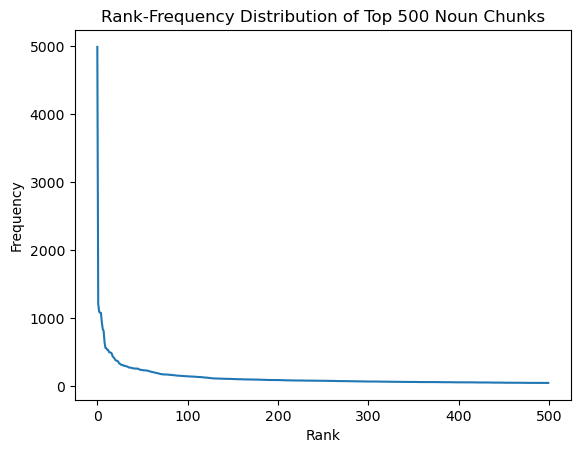

In [ ]:
import matplotlib.pyplot as plt

top_500_chunks = final_counts.most_common(500)

ranks = range(len(top_500_chunks))
frequencies = [count for chunk, count in top_500_chunks]

plt.plot(ranks, frequencies)

plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.title('Rank-Frequency Distribution of Top 500 Noun Chunks')

plt.savefig('noun_chunk_distribution.png')

## 1) j)

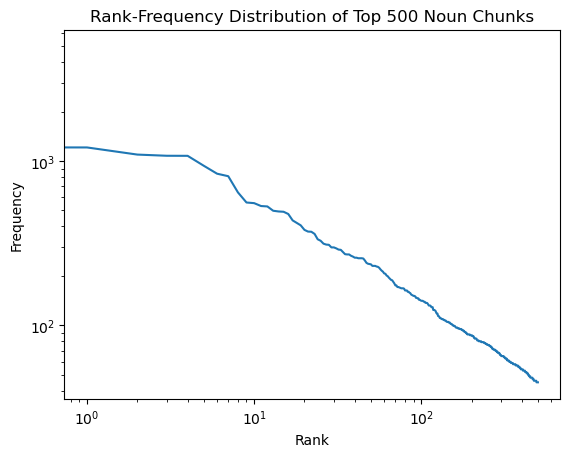

In [ ]:
plt.loglog(ranks, frequencies)

plt.xlabel('Rank')
plt.ylabel('Frequency')
plt.title('Rank-Frequency Distribution of Top 500 Noun Chunks')

plt.savefig('noun_chunk_distribution.png')

## 2)

2) (10 points) Interpret and explain the results obtained in 1h), 1i), and 1j) by relating them to relevant 
concepts introduced in the fourth lecture. You should enter your answer directly into the Jupyter 
notebook for Task 1.  

Answer: 
1h (Hapax Legomena): About 67% of lemmas appear in only one document. This high percentage of Hapax Legomena indicates that the dataset contains a vast amount of specialized, domain-specific vocabulary. While documents share a small core of common terms, they are largely characterized by unique technical descriptions.

1i (Zipf's Law): The frequency distribution follows the classic Zipf's Law, showing a Power Law distribution. A few "head" terms dominate the frequency, while the "long tail" consists of many rare terms.

1j (Log-Log Analysis): The log-log plot reveals a near-linear relationship, confirming the statistical properties of natural language. The slower decay in the top ranks suggests a set of highly related core concepts shared across medical documents (e.g., "treatment," "symptoms"), whereas the divergence in lower ranks reflects the distinct characteristics of each individual disease.

## 3)

3) (7 points) Frequency Class: What does the frequency class (FC) of a word w in a text corpus represent, 
and how is it defined? What does it mean to filter out words with an FC of 0, 1, or 2 when a general
language corpus is used? Which group of words is typically removed when applying this filter? What 
is the relationship between the frequency of words in FC n+1 compared to FC n? You should enter 
your answers directly into the Jupyter notebook for Task 1.  

Answer: 
Definition and Determination: The Frequency Class (FC) of a word  represents its relative rarity compared to the most frequent word in a corpus (usually "the"). It is defined using a base-2 logarithm. In the formula, the class is determined by the power of 2 that represents the frequency gap between the target word and the most frequent word.

Filtering FC 0, 1, and 2:
Filtering out words with an FC of 0, 1, or 2 means removing the most common words in a general language corpus. These are typically function words (stop words) such as articles, prepositions, and conjunctions (e.g., "the," "is," "at"). These words are often removed because they lack semantic distinctiveness and appear across almost all documents regardless of the topic.

Relationship between FC n  and FC n+1 :
The relationship is exponential. A word in fc n+1 occurs approximately half as frequently as a word in fc n. Essentially, as the Frequency Class index increases by 1, the occurrence frequency of the words in that class decreases by a factor of 2.

## 4)

In [82]:
training_text="""Paula|PROPN and|CCONJ Patrick|PROPN are|AUX planning|VERB their|PRON meeting|NOUN 
at|ADP the|DET park|NOUN .|PUNCT 
During|ADP their|PRON meeting|NOUN ,|PUNCT they|PRON watch|VERB other|ADJ people|NOUN 
.|PUNCT 
Afterwards|ADV ,|PUNCT Patrick|PROPN attends|VERB an|DET online|ADJ meeting|NOUN .|PUNCT 
Later|ADV ,|PUNCT Paula|PROPN is|AUX meeting|VERB her|PRON mother|NOUN .|PUNCT"""

sentences = training_text.strip().split('\n')
training_data_by_sentence = []

for sent in sentences:
    sent_tuples = [(pair.split('|')[0].lower(), pair.split('|')[1]) for pair in sent.split() if '|' in pair]
    training_data_by_sentence.append(sent_tuples)

print(training_data_by_sentence[0])

[('paula', 'PROPN'), ('and', 'CCONJ'), ('patrick', 'PROPN'), ('are', 'AUX'), ('planning', 'VERB'), ('their', 'PRON'), ('meeting', 'NOUN')]


In [83]:
testS = """Paula|PROPN and|CCONJ Patrick|PROPN are|AUX meeting other|ADJ people|NOUN .|PUNCT"""

test = []
test = [(pair.split('|')[0].lower(), pair.split('|')[1]) for pair in testS.split() if '|' in pair]
test.append(test)

print(test)

[('paula', 'PROPN'), ('and', 'CCONJ'), ('patrick', 'PROPN'), ('are', 'AUX'), ('other', 'ADJ'), ('people', 'NOUN'), ('.', 'PUNCT'), [...]]


In [86]:
pos_all_counts = Counter()
word_counts = Counter()

for s in training_data_by_sentence:
    pos_counts = Counter([tag for word, tag in s])
    pos_all_counts.update(pos_counts)
    word_counts.update(s)

print(pos_all_counts)
print(word_counts)

Counter({'PUNCT': 7, 'NOUN': 6, 'PROPN': 4, 'VERB': 4, 'PRON': 4, 'AUX': 2, 'ADP': 2, 'DET': 2, 'ADJ': 2, 'ADV': 2, 'CCONJ': 1})
Counter({('.', 'PUNCT'): 4, ('meeting', 'NOUN'): 3, (',', 'PUNCT'): 3, ('paula', 'PROPN'): 2, ('patrick', 'PROPN'): 2, ('their', 'PRON'): 2, ('and', 'CCONJ'): 1, ('are', 'AUX'): 1, ('planning', 'VERB'): 1, ('at', 'ADP'): 1, ('the', 'DET'): 1, ('park', 'NOUN'): 1, ('during', 'ADP'): 1, ('they', 'PRON'): 1, ('watch', 'VERB'): 1, ('other', 'ADJ'): 1, ('people', 'NOUN'): 1, ('afterwards', 'ADV'): 1, ('attends', 'VERB'): 1, ('an', 'DET'): 1, ('online', 'ADJ'): 1, ('later', 'ADV'): 1, ('is', 'AUX'): 1, ('meeting', 'VERB'): 1, ('her', 'PRON'): 1, ('mother', 'NOUN'): 1})


## 1. Unigram Model Calculation
The Unigram model predicts the tag based on the word's conditional probability and its prior probability.
Formula: Score(tag) = P(word|tag) * P(tag)

In [88]:
all_possible_tags = pos_all_counts.keys()

for tag in all_possible_tags:
    p_tag = word_counts[('meeting', tag)] / pos_all_counts[tag]
    
    if p_tag > 0:
        print(f"[{tag}]is possible. {p_tag:.4f}")
    else:
        pass

[VERB]is possible. 0.2500
[NOUN]is possible. 0.5000


## 2. Bigram Model Calculation (Context: "are|AUX")
The Bigram model considers the previous tag (AUX).
Formula: Score(tag) = P(word|tag) * P(tag | prev_tag)

In [89]:
transition_counts = Counter()
for s in training_data_by_sentence:
    tags = [tag for word, tag in s]
    pairs = [(tags[i], tags[i+1]) for i in range(len(tags)-1)]
    transition_counts.update(pairs)

for tag in all_possible_tags:
    p_tag = word_counts[("meeting", tag)] / pos_all_counts[tag]
    p_prev_tag= transition_counts[("AUX", tag)] / pos_all_counts["AUX"]
    p_all = p_tag * p_prev_tag
    print(f"Bigram P({tag} | AUX): {p_all:.4f}")

Bigram P(PROPN | AUX): 0.0000
Bigram P(CCONJ | AUX): 0.0000
Bigram P(AUX | AUX): 0.0000
Bigram P(VERB | AUX): 0.2500
Bigram P(PRON | AUX): 0.0000
Bigram P(NOUN | AUX): 0.0000
Bigram P(ADP | AUX): 0.0000
Bigram P(DET | AUX): 0.0000
Bigram P(PUNCT | AUX): 0.0000
Bigram P(ADJ | AUX): 0.0000
Bigram P(ADV | AUX): 0.0000
